# Mobile SAM

In [ ]:
!git clone -q https://github.com/ChaoningZhang/MobileSAM.git
%cd /content/MobileSAM

!pip install -q -r requirements.txt
!pip install -q opencv-python matplotlib

/content/MobileSAM
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
!pip install -q torch torchvision opencv-python matplotlib numpy pillow

In [ ]:
!ls -la /content/MobileSAM

total 92
drwxr-xr-x 10 root root  4096 Aug 19 06:51 .
drwxr-xr-x  1 root root  4096 Aug 19 06:51 ..
drwxr-xr-x  4 root root  4096 Aug 19 06:51 app
drwxr-xr-x  2 root root  4096 Aug 19 06:51 assets
-rw-r--r--  1 root root  3541 Aug 19 06:51 CODE_OF_CONDUCT.md
-rw-r--r--  1 root root  1400 Aug 19 06:51 CONTRIBUTING.md
drwxr-xr-x  8 root root  4096 Aug 19 06:51 .git
-rw-r--r--  1 root root    39 Aug 19 06:51 .gitignore
-rw-r--r--  1 root root 11357 Aug 19 06:51 LICENSE
-rwxr-xr-x  1 root root   564 Aug 19 06:51 linter.sh
-rw-r--r--  1 root root   114 Aug 19 06:51 Member.txt
drwxr-xr-x  4 root root  4096 Aug 19 06:51 mobile_sam
drwxr-xr-x  9 root root  4096 Aug 19 06:51 MobileSAMv2
drwxr-xr-x  3 root root  4096 Aug 19 06:51 notebooks
-rw-r--r--  1 root root 10854 Aug 19 06:51 README.md
drwxr-xr-x  2 root root  4096 Aug 19 06:51 scripts
-rw-r--r--  1 root root   365 Aug 19 06:51 setup.cfg
-rw-r--r--  1 root root   535 Aug 19 06:51 setup.py
drwxr-xr-x  2 root root  4096 Aug 19 06:51 weights


In [ ]:
%cd /content/MobileSAM

!pip install -q -e .

/content/MobileSAM
  Preparing metadata (setup.py) ... done


In [ ]:
!mkdir -p /content/MobileSAM/weights

!wget -q \
  https://github.com/ChaoningZhang/MobileSAM/raw/master/weights/mobile_sam.pt \
  -O /content/MobileSAM/weights/mobile_sam.pt

!ls -lh /content/MobileSAM/weights/mobile_sam.pt

-rw-r--r-- 1 root root 39M Aug 19 06:52 /content/MobileSAM/weights/mobile_sam.pt


In [ ]:
import sys
sys.path.insert(0, "/content/MobileSAM")

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from mobile_sam import sam_model_registry, SamAutomaticMaskGenerator

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_t"](
    checkpoint="/content/MobileSAM/weights/mobile_sam.pt"
)

sam.to(device)
sam.eval()

mask_generator = SamAutomaticMaskGenerator(sam)

print("Device:", device)
print("MobileSAM loaded successfully")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/MobileSAM/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/content/MobileSAM/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_11m_224 in registry with mobile_sam.modeling.

Device: cpu
MobileSAM loaded successfully


In [ ]:
from google.colab import files

# uploaded = files.upload()

# img_path = "/content/" + next(iter(uploaded))

image = Image.open("/content/MobileSAM/WhatsApp Image 2026-08-09 at 11.52.00 PM.jpeg").convert("RGB")
# image = Image.open("/content/MobileSAM/tester.jpg").convert("RGB")
image_np = np.array(image)

print("Image size:", image.size)

Image size: (1536, 1024)


In [ ]:
masks = mask_generator.generate(image_np)

print("Number of masks:", len(masks))

Number of masks: 73


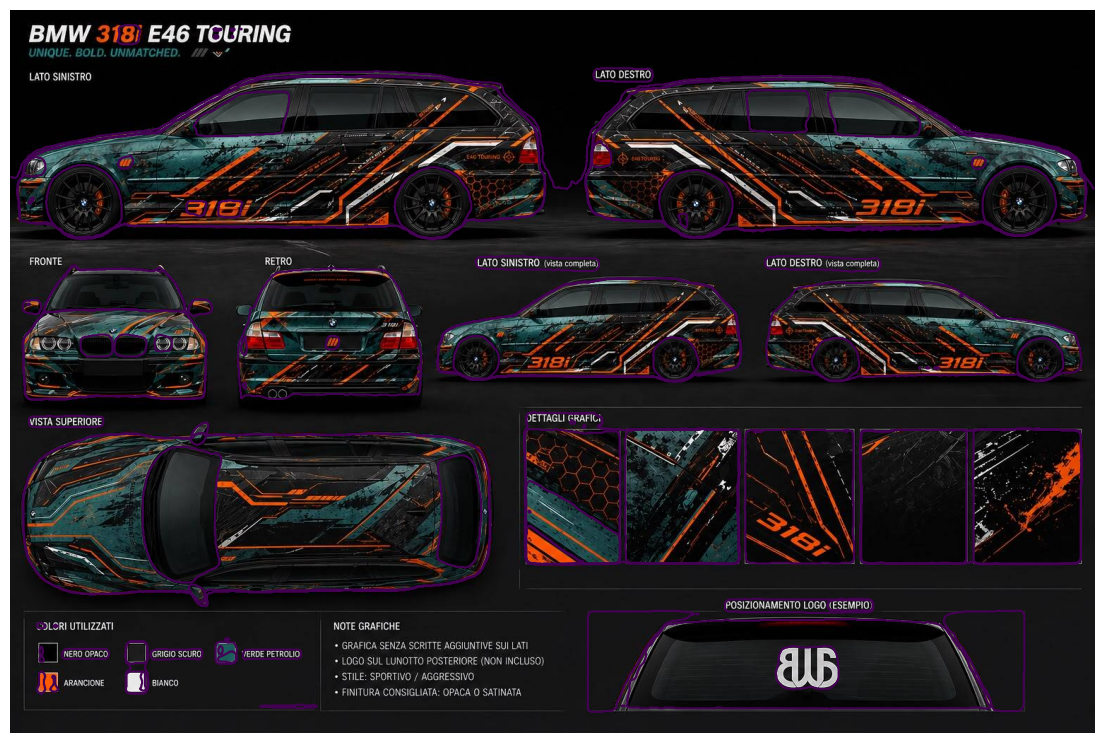

In [ ]:
plt.figure(figsize=(14, 10))
plt.imshow(image_np)

for m in masks:
    plt.contour(
        m["segmentation"],
        levels=[0.5]
    )

plt.axis("off");

In [ ]:
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=16,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.9,
    min_mask_region_area=500
)

masks = mask_generator.generate(image_np)

print("Number of masks:", len(masks))

Number of masks: 71


In [ ]:
H, W = image_np.shape[:2]
image_area = H * W

filtered_masks = []

for mask in masks:
    area = mask["area"]

    # Remove masks covering > 90% of the image
    if area / image_area > 0.90:
        continue

    filtered_masks.append(mask)

masks = filtered_masks

print("Masks after removing background:", len(masks))

Masks after removing background: 71


In [ ]:
import numpy as np

def containment_ratio(mask_a, mask_b):
    """
    How much of mask_b is contained inside mask_a.
    """
    intersection = np.logical_and(mask_a, mask_b).sum()
    area_b = mask_b.sum()

    if area_b == 0:
        return 0

    return intersection / area_b

In [ ]:
filtered_masks = []

for i, current in enumerate(masks):

    current_seg = current["segmentation"]

    contained = False

    for j, other in enumerate(masks):

        if i == j:
            continue

        other_seg = other["segmentation"]

        ratio = containment_ratio(
            other_seg,
            current_seg
        )

        # current mask is almost completely inside another mask
        if ratio > 0.95:
            contained = True
            break

    if not contained:
        filtered_masks.append(current)

masks = filtered_masks

print("Masks after containment filtering:", len(masks))

Masks after containment filtering: 22


In [ ]:
def mask_iou(mask_a, mask_b):

    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()

    if union == 0:
        return 0

    return intersection / union

In [ ]:
  # Sort largest confidence first
masks = sorted(
    masks,
    key=lambda x: x["predicted_iou"],
    reverse=True
)

unique_masks = []

for candidate in masks:

    duplicate = False

    for existing in unique_masks:

        iou = mask_iou(
            candidate["segmentation"],
            existing["segmentation"]
        )

        if iou > 0.90:
            duplicate = True
            break

    if not duplicate:
        unique_masks.append(candidate)

masks = unique_masks

print("Masks after duplicate removal:", len(masks))

Masks after duplicate removal: 22


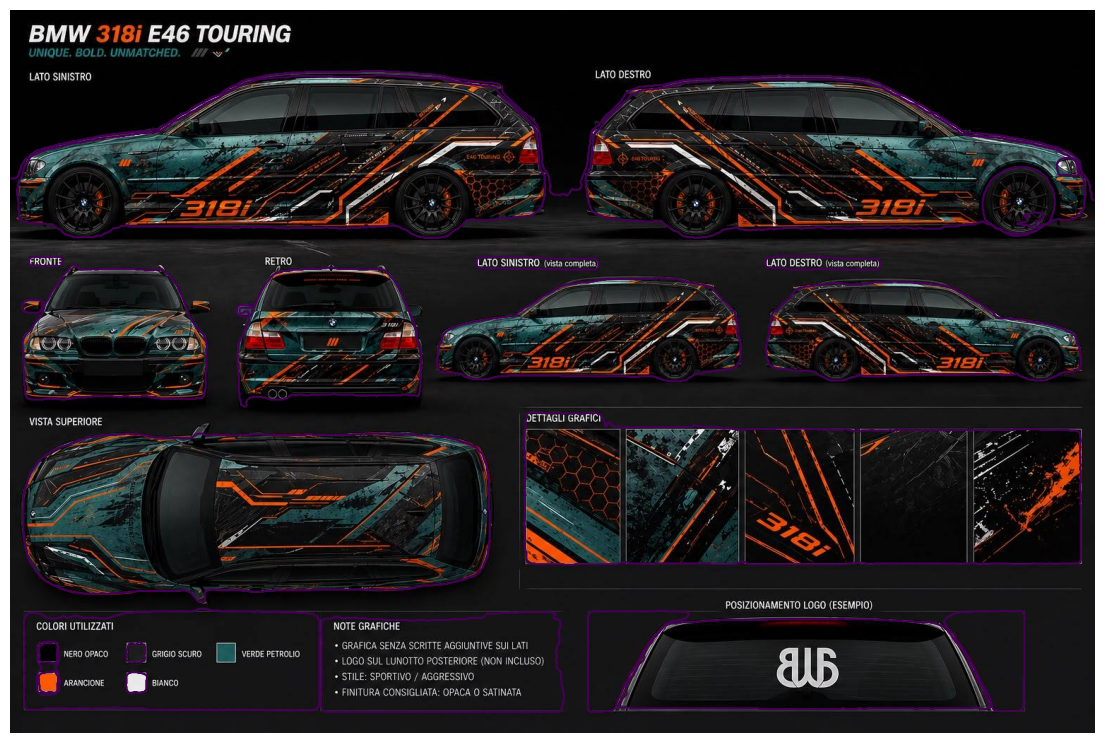

In [ ]:
plt.figure(figsize=(14, 10))
plt.imshow(image_np)

for m in masks:
    plt.contour(
        m["segmentation"],
        levels=[0.5]
    )

plt.axis("off");

# Vtracer

In [ ]:
# !pip install -q vtracer

In [ ]:
import vtracer

print("VTracer installed")

In [ ]:
import os
from PIL import Image

output_dir = "/content/vectorization"
mask_dir = os.path.join(output_dir, "masks")

os.makedirs(mask_dir, exist_ok=True)

# ---------------------------------------------------------
# Create union of all MobileSAM masks
# ---------------------------------------------------------

H, W = image_np.shape[:2]

union_mask = np.zeros((H, W), dtype=bool)

for mask_data in masks:
    mask = mask_data["segmentation"]
    union_mask |= mask

# ---------------------------------------------------------
# Create residual/background mask
# Pixels not covered by ANY SAM mask
# ---------------------------------------------------------

background_mask = ~union_mask

print("Total pixels:", H * W)
print("Covered by SAM:", union_mask.sum())
print("Uncovered/background:", background_mask.sum())

# ---------------------------------------------------------
# Save background mask first
# ---------------------------------------------------------

background_alpha = (
    background_mask.astype(np.uint8) * 255
)

background_rgba = np.dstack([
    image_np,
    background_alpha
])

background_path = os.path.join(
    mask_dir,
    "mask_background.png"
)

Image.fromarray(background_rgba).save(background_path)

image_rgb = Image.fromarray(image_np).convert("RGB")

for i, mask_data in enumerate(masks):

    # Extract actual mask from dictionary
    mask = mask_data["segmentation"]

    alpha = (mask.astype(np.uint8) * 255)

    rgba = np.dstack([
        image_np,
        alpha
    ])

    Image.fromarray(rgba).save(
        f"{mask_dir}/mask_{i:03d}.png"
    )

print("Saved", len(masks), "masked PNGs")

In [ ]:
svg_dir = os.path.join(output_dir, "svg")
os.makedirs(svg_dir, exist_ok=True)

svg_files = []

# ---------------------------------------------------------
# Vectorize background
# ---------------------------------------------------------

background_png = os.path.join(
    mask_dir,
    "mask_background.png"
)

background_svg = os.path.join(
    svg_dir,
    "mask_background.svg"
)

vtracer.convert_image_to_svg_py(
    background_png,
    background_svg,
    colormode="color",
    hierarchical="stacked",
    mode="spline",
    filter_speckle=1,
    color_precision=8,
    layer_difference=16,
    corner_threshold=60,
    length_threshold=4,
    max_iterations=10,
    path_precision=3
)

svg_files.append(
    ("background", background_svg)
)


for i in range(len(masks)):

    input_png = f"{mask_dir}/mask_{i:03d}.png"
    output_svg = f"{svg_dir}/mask_{i:03d}.svg"

    vtracer.convert_image_to_svg_py(
        input_png,
        output_svg,
        colormode="color",
        hierarchical="stacked",
        mode="spline",
        filter_speckle=1,
        color_precision=8,
        layer_difference=16,
        corner_threshold=60,
        length_threshold=4,
        max_iterations=10,
        path_precision=3
    )

    svg_files.append(output_svg)

print("Vectorized:", len(svg_files))

In [ ]:
import os
import re
import glob

svg_dir = "/content/vectorization/svg"

svg_parts = []

# ---------------------------------------------------------
# 1. Background FIRST
# ---------------------------------------------------------

background_svg = os.path.join(
    svg_dir,
    "mask_background.svg"
)

if os.path.exists(background_svg):

    with open(background_svg, "r", encoding="utf-8") as f:
        svg = f.read()

    match = re.search(
        r"<svg[^>]*>(.*?)</svg>",
        svg,
        re.DOTALL
    )

    if match:
        svg_parts.append(
            f"""
            <g id="layer-background"
               data-layer="background">
                {match.group(1)}
            </g>
            """
        )

        print("Added background")


# ---------------------------------------------------------
# 2. Find all MobileSAM SVGs
# ---------------------------------------------------------

mask_svg_files = sorted(
    glob.glob(
        os.path.join(svg_dir, "mask_*.svg")
    )
)

# Don't accidentally include background
mask_svg_files = [
    path for path in mask_svg_files
    if not path.endswith("mask_background.svg")
]

print("Found", len(mask_svg_files), "mask SVGs")


# ---------------------------------------------------------
# 3. Add MobileSAM layers
# ---------------------------------------------------------

for i, svg_file in enumerate(mask_svg_files):

    with open(svg_file, "r", encoding="utf-8") as f:
        svg = f.read()

    match = re.search(
        r"<svg[^>]*>(.*?)</svg>",
        svg,
        re.DOTALL
    )

    if not match:
        print("Skipping:", svg_file)
        continue

    content = match.group(1)

    svg_parts.append(
        f"""
        <g id="layer-mask-{i}"
           data-layer="mask-{i}">
            {content}
        </g>
        """
    )


# ---------------------------------------------------------
# 4. Create final SVG
# ---------------------------------------------------------

H, W = image_np.shape[:2]

combined_svg = f"""<?xml version="1.0" encoding="UTF-8"?>
<svg
    xmlns="http://www.w3.org/2000/svg"
    width="{W}"
    height="{H}"
    viewBox="0 0 {W} {H}"
>
    {"".join(svg_parts)}
</svg>
"""


# ---------------------------------------------------------
# 5. Save
# ---------------------------------------------------------

combined_path = "/content/vectorization/result.svg"

with open(combined_path, "w", encoding="utf-8") as f:
    f.write(combined_svg)

print()
print("Created:", combined_path)
print("Total layers:", len(svg_parts))

In [ ]:
# ---------------------------------------------------------
# 6. Delete intermediate PNGs and SVGs
# ---------------------------------------------------------

deleted_pngs = 0
deleted_svgs = 0

# Delete individual masked/cropped PNGs
if os.path.exists(mask_dir):

    for png_file in glob.glob(
        os.path.join(mask_dir, "*.png")
    ):
        try:
            os.remove(png_file)
            deleted_pngs += 1
        except Exception as e:
            print("Could not delete:", png_file, e)


# Delete individual SVG files
if os.path.exists(svg_dir):

    for svg_file in glob.glob(
        os.path.join(svg_dir, "*.svg")
    ):
        try:
            os.remove(svg_file)
            deleted_svgs += 1
        except Exception as e:
            print("Could not delete:", svg_file, e)


print("Deleted PNGs:", deleted_pngs)
print("Deleted intermediate SVGs:", deleted_svgs)
print("Final SVG preserved:", combined_path)

In [ ]:
from IPython.display import SVG, display

display(SVG(filename=combined_path))

# FastSAM

In [ ]:
!pip install -q ultralytics

In [ ]:
from ultralytics import FastSAM
import torch

device = 0 if torch.cuda.is_available() else "cpu"

model = FastSAM("FastSAM-s.pt")

print("Device:", device)
print("FastSAM loaded")

Device: cpu
FastSAM loaded


In [ ]:
from google.colab import files

# uploaded = files.upload()

img_path = "/content/MobileSAM/tester.jpg"

print("Image:", img_path)

Image: /content/MobileSAM/tester.jpg


In [ ]:
results = model(
    img_path,
    device=device,
    retina_masks=True,
    imgsz=1024,
    conf=0.4
)

result = results[0]

print(result)


image 1/1 /content/MobileSAM/tester.jpg: 640x1024 51 objects, 3277.7ms
Speed: 19.6ms preprocess, 3277.7ms inference, 938.4ms postprocess per image at shape (1, 3, 640, 1024)
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'object'}
obb: None
orig_img: array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
      

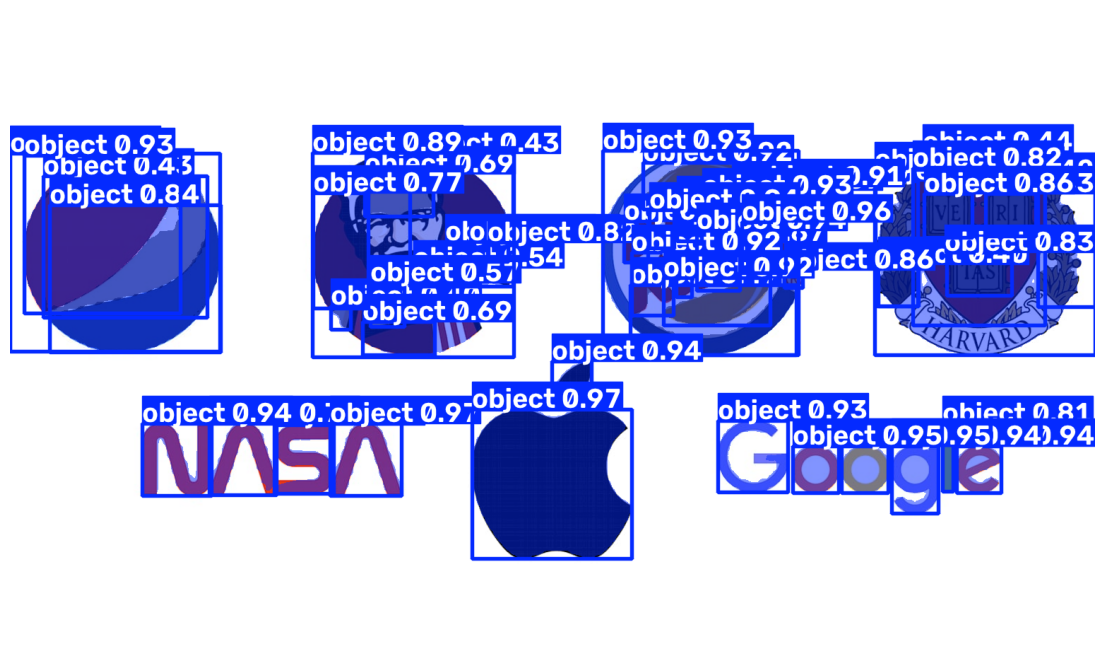

In [ ]:
import matplotlib.pyplot as plt

annotated = result.plot()

plt.figure(figsize=(14, 10))
plt.imshow(annotated[..., ::-1])
plt.axis("off");

In [ ]:
if result.masks is not None:
    masks = result.masks.data.cpu().numpy()

    print("Number of masks:", len(masks))
    print("Mask dimensions:", masks.shape)
else:
    print("No masks detected")

Number of masks: 51
Mask dimensions: (51, 922, 1536)


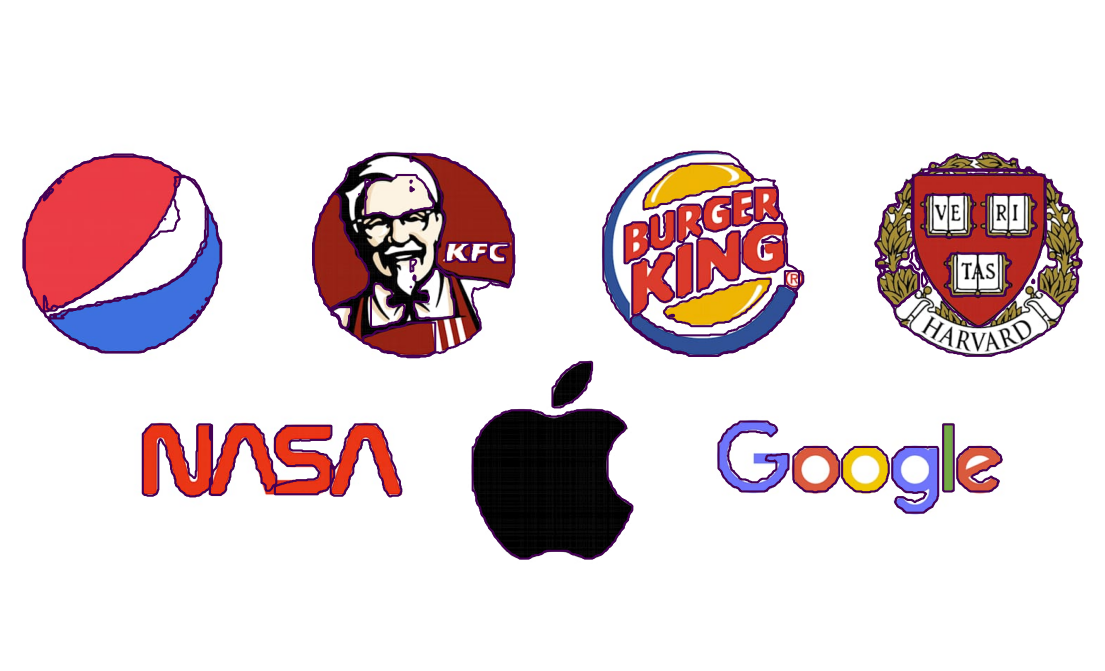

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
plt.imshow(np.array(result.orig_img)[..., ::-1])

for mask in masks:
    plt.contour(mask, levels=[0.5])

plt.axis("off");

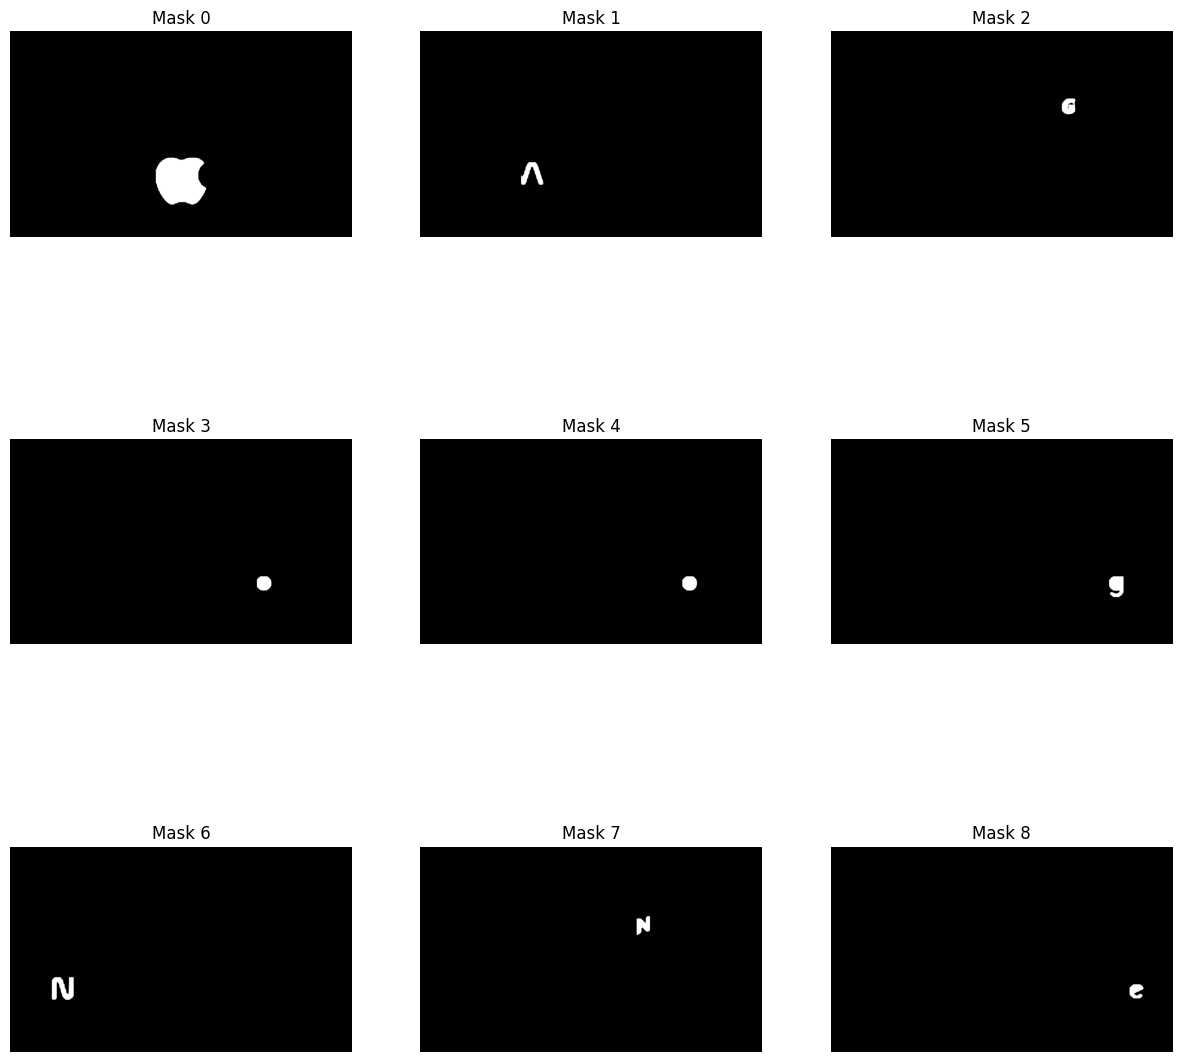

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    if i >= len(masks):
        ax.axis("off")
        continue

    ax.imshow(masks[i], cmap="gray")
    ax.set_title(f"Mask {i}")
    ax.axis("off")

plt.show()

auto

In [ ]:
results = model(
    img_path,
    device=device,
    retina_masks=True,
    imgsz=1024,
    conf=0.4
)


image 1/1 /content/MobileSAM/WhatsApp Image 2026-08-09 at 11.52.00 PM.jpeg: 704x1024 112 objects, 1749.9ms
Speed: 8.7ms preprocess, 1749.9ms inference, 2673.1ms postprocess per image at shape (1, 3, 704, 1024)


# Vtracer

In [ ]:
# !pip install -q vtracer

In [ ]:
import vtracer

print("VTracer installed")

ModuleNotFoundError: No module named 'vtracer'

In [ ]:
import os
from PIL import Image

output_dir = "/content/vectorization"
mask_dir = os.path.join(output_dir, "masks")

os.makedirs(mask_dir, exist_ok=True)

image_rgb = Image.fromarray(image_np).convert("RGB")

for i, mask in enumerate(masks):

    # Convert mask to alpha
    alpha = (mask.astype("uint8") * 255)

    rgba = np.dstack([
        image_np,
        alpha
    ])

    Image.fromarray(rgba).save(
        f"{mask_dir}/mask_{i:03d}.png"
    )

print("Saved", len(masks), "masked PNGs")

In [ ]:
svg_dir = os.path.join(output_dir, "svg")
os.makedirs(svg_dir, exist_ok=True)

svg_files = []

for i in range(len(masks)):

    input_png = f"{mask_dir}/mask_{i:03d}.png"
    output_svg = f"{svg_dir}/mask_{i:03d}.svg"

    vtracer.convert_image_to_svg_py(
        input_png,
        output_svg,
        colormode="color",
        hierarchical="stacked",
        mode="spline",
        filter_speckle=4,
        color_precision=6,
        layer_difference=16,
        corner_threshold=60,
        length_threshold=4,
        max_iterations=10,
        path_precision=3
    )

    svg_files.append(output_svg)

print("Vectorized:", len(svg_files))

In [ ]:
import re
import html

svg_parts = []

for i, svg_file in enumerate(svg_files):

    with open(svg_file, "r", encoding="utf-8") as f:
        svg = f.read()

    # Extract everything inside the root <svg>
    match = re.search(
        r"<svg[^>]*>(.*?)</svg>",
        svg,
        re.DOTALL
    )

    if not match:
        continue

    content = match.group(1)

    group = f"""
    <g id="layer-{i}" data-layer="mask-{i}">
        {content}
    </g>
    """

    svg_parts.append(group)

combined_svg = f"""<?xml version="1.0" encoding="UTF-8"?>
<svg
    xmlns="http://www.w3.org/2000/svg"
    width="{image_np.shape[1]}"
    height="{image_np.shape[0]}"
    viewBox="0 0 {image_np.shape[1]} {image_np.shape[0]}"
>
    {"".join(svg_parts)}
</svg>
"""

combined_path = "/content/vectorization/result.svg"

with open(combined_path, "w", encoding="utf-8") as f:
    f.write(combined_svg)

print("Created:", combined_path)

In [ ]:
from IPython.display import SVG, display

display(SVG(filename=combined_path))